# 📈 S&P 500 Stock Price Prediction
### Random Forest · XGBoost · LSTM
---
**Workflow:**
1. Pick a company from the dropdown
2. Run All Cells (`Kernel → Restart & Run All`)
3. Results appear automatically — charts, metrics, and a 20-day forecast


In [15]:
import os, warnings, time
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from scipy import stats

# Widgets
import ipywidgets as widgets
from IPython.display import display as ipy_display, clear_output

# ML
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# LSTM
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping

# Reproducibility
import random
def set_seeds(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)

set_seeds()

plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
print("✅ Libraries loaded.")
print(f"   TensorFlow: {tf.__version__}  |  NumPy: {np.__version__}  |  Pandas: {pd.__version__}")


✅ Libraries loaded.
   TensorFlow: 2.21.0  |  NumPy: 2.3.4  |  Pandas: 2.3.3


## 1. Load Data

In [16]:
# ── Paths (edit if your folder structure is different) ──
BASE = os.path.join(os.getcwd(), '..', 'data', 'raw')
df_stocks_raw  = pd.read_csv(os.path.join(BASE, 'sp500_stocks.csv'))
df_index_raw   = pd.read_csv(os.path.join(BASE, 'sp500_index.csv'))
df_companies_raw = pd.read_csv(os.path.join(BASE, 'sp500_companies.csv'))

# Clean column whitespace once
for _df in [df_stocks_raw, df_index_raw, df_companies_raw]:
    _df.columns = _df.columns.str.strip()

df_stocks_raw['Symbol'] = df_stocks_raw['Symbol'].astype(str).str.strip()
df_companies_raw['Symbol'] = df_companies_raw['Symbol'].astype(str).str.strip()
df_index_raw['Date'] = pd.to_datetime(df_index_raw['Date'])

# Only keep tickers with at least 2000 trading days of real price data
_cov = df_stocks_raw.dropna(subset=['Close']).groupby('Symbol').size()
GOOD_TICKERS = sorted(_cov[_cov >= 2000].index.tolist())

print(f"✅ Data loaded.  Available companies for analysis: {len(GOOD_TICKERS)}")


✅ Data loaded.  Available companies for analysis: 165


## 2. Select Company

In [17]:
ticker_dropdown = widgets.Dropdown(
    options=GOOD_TICKERS,
    value='MSFT',
    description='Company:',
    style={'description_width': 'initial'},
    layout=widgets.Layout(width='320px')
)

print("👇  Pick a company, then run the cells below (or Restart & Run All).")
ipy_display(ticker_dropdown)


👇  Pick a company, then run the cells below (or Restart & Run All).


Dropdown(description='Company:', index=103, layout=Layout(width='320px'), options=('ABBV', 'ABT', 'ADM', 'AES'…

## 3. Filter & Prepare Data

In [18]:
TICKER = ticker_dropdown.value

# Filter stocks
_s = df_stocks_raw.copy()
df = _s[_s['Symbol'].str.upper() == TICKER.upper()].copy()
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date').reset_index(drop=True)
df.dropna(subset=['Close'], inplace=True)

# Merge S&P500 index
df = pd.merge(df, df_index_raw[['Date','S&P500']], on='Date', how='left')

# Merge company metadata
df = pd.merge(df, df_companies_raw[['Symbol','Longname','Sector']], on='Symbol', how='left')

# Drop rows before index data starts (pre-Dec 2014)
df.dropna(subset=['S&P500'], inplace=True)
df.reset_index(drop=True, inplace=True)

COMPANY_NAME = df['Longname'].iloc[0] if pd.notna(df['Longname'].iloc[0]) else TICKER
SECTOR       = df['Sector'].iloc[0]   if pd.notna(df['Sector'].iloc[0])   else 'N/A'

print("=" * 55)
print(f"  {COMPANY_NAME}  ({TICKER})")
print(f"  Sector : {SECTOR}")
print(f"  Period : {df['Date'].iloc[0].date()} → {df['Date'].iloc[-1].date()}")
print(f"  Rows   : {len(df):,} trading days")
print("=" * 55)


  Microsoft Corporation  (MSFT)
  Sector : Technology
  Period : 2014-12-22 → 2024-12-20
  Rows   : 2,517 trading days


## 4. Exploratory Analysis

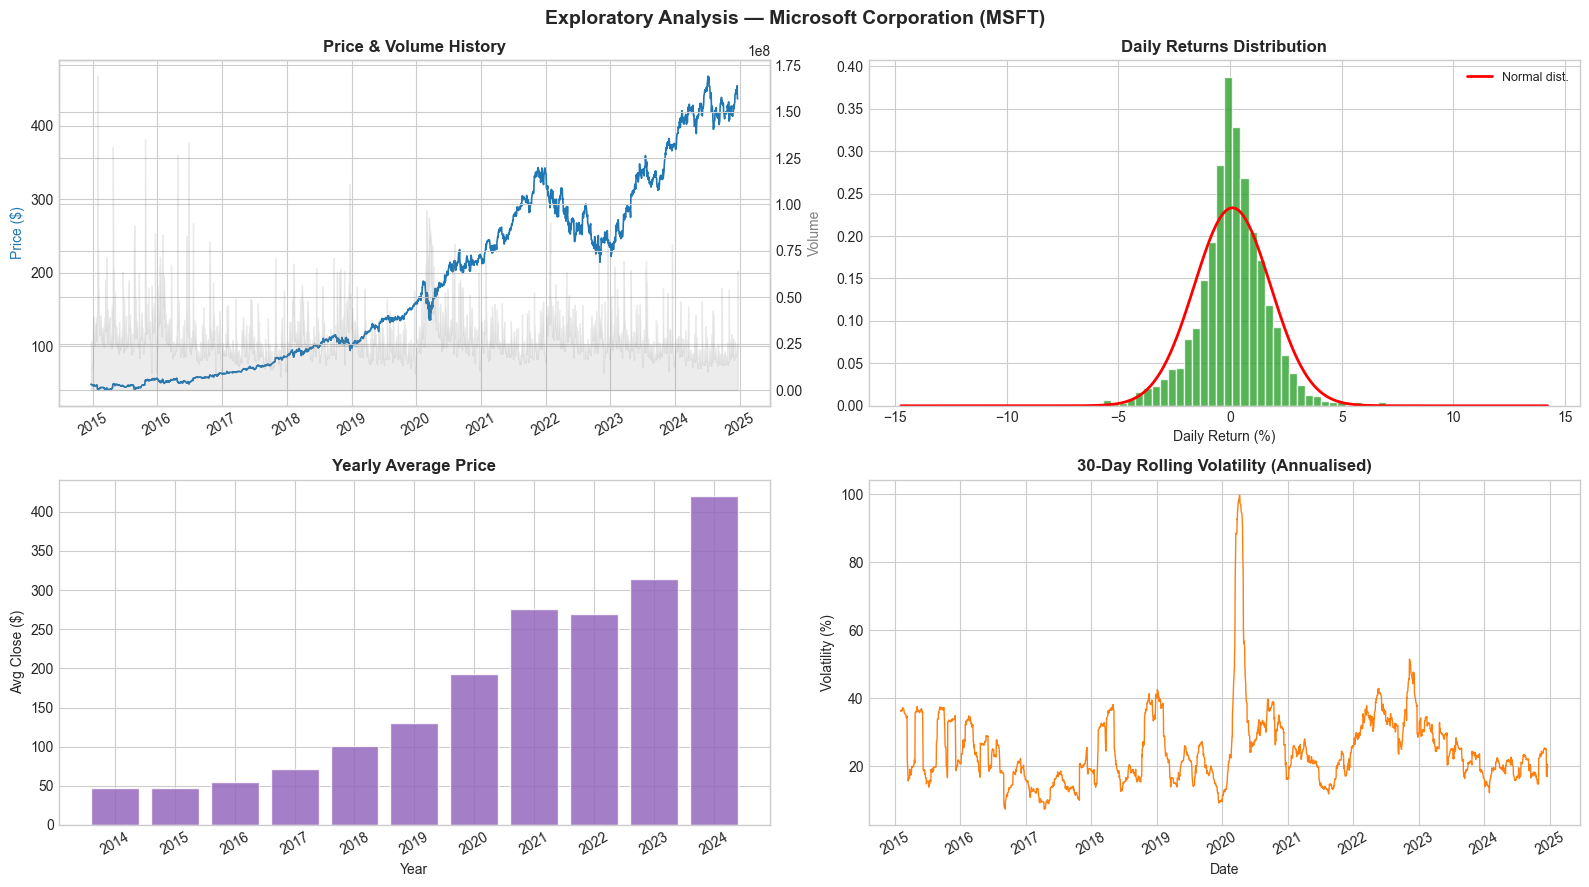

In [19]:
fig, axes = plt.subplots(2, 2, figsize=(16, 9))
fig.suptitle(f'Exploratory Analysis — {COMPANY_NAME} ({TICKER})', fontsize=14, fontweight='bold')

# 1) Price + Volume
ax1 = axes[0, 0]
ax2 = ax1.twinx()
ax1.plot(df['Date'], df['Close'], color='#1f77b4', linewidth=1.2, label='Close price')
ax2.fill_between(df['Date'], df['Volume'], color='gray', alpha=0.15)
ax1.set_title('Price & Volume History', fontweight='bold')
ax1.set_ylabel('Price ($)', color='#1f77b4')
ax2.set_ylabel('Volume', color='gray')
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax1.tick_params(axis='x', rotation=30)

# 2) Daily returns distribution
df['Daily_Return'] = df['Close'].pct_change().fillna(0)
returns_pct = df['Daily_Return'] * 100
axes[0, 1].hist(returns_pct, bins=80, color='#2ca02c', edgecolor='white', alpha=0.8, density=True)
mu, sigma = returns_pct.mean(), returns_pct.std()
x = np.linspace(returns_pct.min(), returns_pct.max(), 200)
axes[0, 1].plot(x, stats.norm.pdf(x, mu, sigma), 'r-', linewidth=2, label='Normal dist.')
axes[0, 1].set_title('Daily Returns Distribution', fontweight='bold')
axes[0, 1].set_xlabel('Daily Return (%)')
axes[0, 1].legend(fontsize=9)

# 3) Yearly average price
df['Year'] = df['Date'].dt.year
yearly = df.groupby('Year')['Close'].mean()
axes[1, 0].bar(yearly.index.astype(str), yearly.values, color='#9467bd', edgecolor='white', alpha=0.85)
axes[1, 0].set_title('Yearly Average Price', fontweight='bold')
axes[1, 0].set_xlabel('Year')
axes[1, 0].set_ylabel('Avg Close ($)')
axes[1, 0].tick_params(axis='x', rotation=30)
df.drop(columns=['Year'], inplace=True, errors='ignore')

# 4) Rolling 30d volatility
rolling_vol = df['Daily_Return'].rolling(30).std() * np.sqrt(252) * 100
axes[1, 1].plot(df['Date'], rolling_vol, color='#ff7f0e', linewidth=1)
axes[1, 1].set_title('30-Day Rolling Volatility (Annualised)', fontweight='bold')
axes[1, 1].set_xlabel('Date')
axes[1, 1].set_ylabel('Volatility (%)')
axes[1, 1].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
axes[1, 1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()


## 5. Feature Engineering

In [20]:
df_ml = df.copy()

# ── Trend indicators ──
df_ml['MA_7']   = df_ml['Close'].rolling(7).mean()
df_ml['MA_21']  = df_ml['Close'].rolling(21).mean()
df_ml['EMA_12'] = df_ml['Close'].ewm(span=12, adjust=False).mean()
df_ml['EMA_26'] = df_ml['Close'].ewm(span=26, adjust=False).mean()

# ── Derived features ──
df_ml['MA_Diff']   = df_ml['MA_7']  - df_ml['MA_21']
df_ml['EMA_Spread']= df_ml['EMA_12']- df_ml['EMA_26']

# ── Bollinger Bands ──
_std = df_ml['Close'].rolling(7).std()
df_ml['BB_Upper'] = df_ml['MA_7'] + 2 * _std
df_ml['BB_Lower'] = df_ml['MA_7'] - 2 * _std
df_ml['BB_Width'] = (df_ml['BB_Upper'] - df_ml['BB_Lower']) / (df_ml['MA_7'] + 1e-9)

# ── RSI (Wilder) ──
_delta = df_ml['Close'].diff()
_gain  = _delta.clip(lower=0).ewm(alpha=1/14, adjust=False).mean()
_loss  = (-_delta.clip(upper=0)).ewm(alpha=1/14, adjust=False).mean()
df_ml['RSI'] = 100 - (100 / (1 + _gain / (_loss + 1e-9)))

# ── Momentum & Volatility ──
df_ml['Momentum_5']   = df_ml['Close'] - df_ml['Close'].shift(5)
df_ml['Momentum_10']  = df_ml['Close'] - df_ml['Close'].shift(10)

# Winsorise returns before using as feature
_q1, _q3 = df_ml['Daily_Return'].quantile([0.25, 0.75])
_iqr = _q3 - _q1
df_ml['Return_Clean'] = df_ml['Daily_Return'].clip(_q1 - 1.5*_iqr, _q3 + 1.5*_iqr)
df_ml['Volatility_7'] = df_ml['Return_Clean'].rolling(7).std()

# ── Lag & Target ──
df_ml['Close_Lag1'] = df_ml['Close'].shift(1)
df_ml['Target']     = df_ml['Close'].shift(-1)   # Next day's price

df_ml.dropna(inplace=True)
df_ml.reset_index(drop=True, inplace=True)

FEATURES = ['MA_Diff', 'EMA_Spread', 'BB_Width', 'RSI',
            'Momentum_5', 'Momentum_10', 'Volatility_7',
            'Return_Clean', 'Close_Lag1']

print(f"✅ Feature engineering done.  Shape: {df_ml.shape[0]:,} rows × {df_ml.shape[1]} columns")
print(f"   Features used for ML: {FEATURES}")


✅ Feature engineering done.  Shape: 2,496 rows × 28 columns
   Features used for ML: ['MA_Diff', 'EMA_Spread', 'BB_Width', 'RSI', 'Momentum_5', 'Momentum_10', 'Volatility_7', 'Return_Clean', 'Close_Lag1']


## 6. Train / Test Split  (80 / 20 chronological)

Train: 2015-01-22 → 2022-12-22  (1,996 days)
Test : 2022-12-23 → 2024-12-19  (500 days)


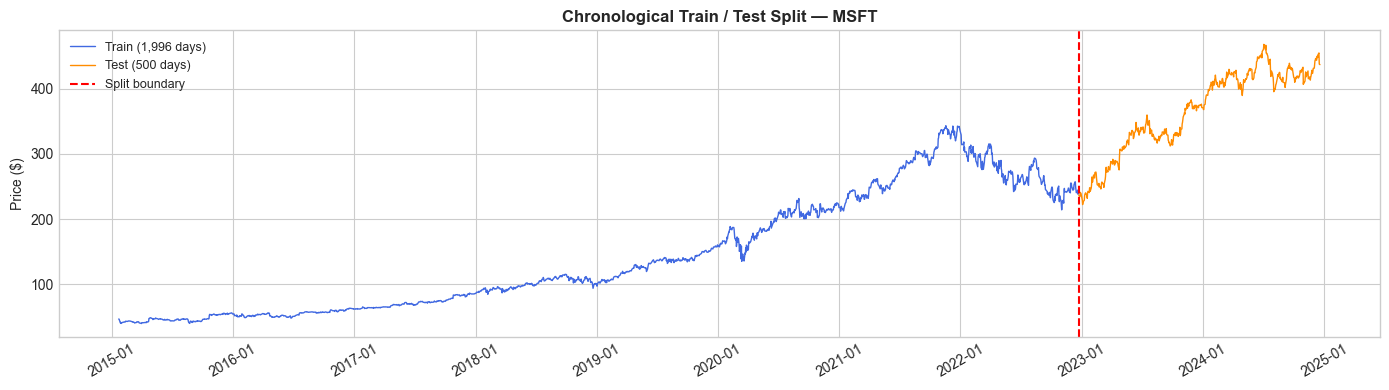

In [21]:
SPLIT = int(len(df_ml) * 0.80)

X = df_ml[FEATURES]
y = df_ml['Target']

X_train_raw = X.iloc[:SPLIT]
X_test_raw  = X.iloc[SPLIT:]
y_train     = y.iloc[:SPLIT]
y_test      = y.iloc[SPLIT:]
test_dates  = df_ml['Date'].iloc[SPLIT:].reset_index(drop=True)

# StandardScaler — fit only on train
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_raw)
X_test  = scaler.transform(X_test_raw)

# Naive baseline: predict today's price as tomorrow's
y_baseline = X_test_raw['Close_Lag1'].values

print(f"Train: {df_ml['Date'].iloc[0].date()} → {df_ml['Date'].iloc[SPLIT-1].date()}  ({len(y_train):,} days)")
print(f"Test : {df_ml['Date'].iloc[SPLIT].date()} → {df_ml['Date'].iloc[-1].date()}  ({len(y_test):,} days)")

# ── Visualise the split ──
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(df_ml['Date'].iloc[:SPLIT], y_train, color='royalblue', linewidth=1, label=f'Train ({len(y_train):,} days)')
ax.plot(df_ml['Date'].iloc[SPLIT:],  y_test,  color='darkorange', linewidth=1, label=f'Test ({len(y_test):,} days)')
ax.axvline(df_ml['Date'].iloc[SPLIT], color='red', linestyle='--', linewidth=1.5, label='Split boundary')
ax.set_title(f'Chronological Train / Test Split — {TICKER}', fontweight='bold')
ax.set_ylabel('Price ($)')
ax.legend(fontsize=9)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()


## 7. Train Models

### 7a. Random Forest & XGBoost

In [22]:
set_seeds()

models = {
    'Random Forest': RandomForestRegressor(
        n_estimators=300, max_depth=8, min_samples_leaf=3,
        n_jobs=-1, random_state=42
    ),
    'XGBoost': XGBRegressor(
        n_estimators=300, learning_rate=0.03, max_depth=5,
        subsample=0.8, colsample_bytree=0.8,
        random_state=42, verbosity=0
    ),
}

for name, model in models.items():
    t0 = time.time()
    model.fit(X_train, y_train)
    print(f"✅ {name:<20} trained in {time.time()-t0:.1f}s")

print("\nAll tree-based models ready.")


✅ Random Forest        trained in 0.5s
✅ XGBoost              trained in 0.2s

All tree-based models ready.


### 7b. LSTM Neural Network

✅ LSTM trained in 25.6s  (33 epochs)


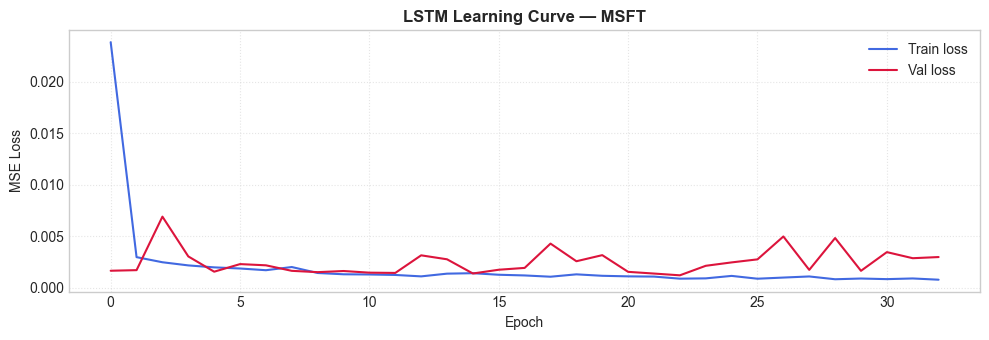

In [23]:
LOOKBACK = 20   # trading days the LSTM sees before predicting

# MinMax scale Close prices separately for LSTM
lstm_scaler = MinMaxScaler()
train_prices = df_ml['Close'].iloc[:SPLIT].values.reshape(-1, 1)
lstm_scaler.fit(train_prices)

# Build sequences
def make_sequences(prices_scaled, lookback):
    X_seq, y_seq = [], []
    for i in range(lookback, len(prices_scaled)):
        X_seq.append(prices_scaled[i-lookback:i, 0])
        y_seq.append(prices_scaled[i, 0])
    return np.array(X_seq).reshape(-1, lookback, 1), np.array(y_seq)

# For test we need LOOKBACK days of history before the test window
all_prices_scaled = lstm_scaler.transform(df_ml['Close'].values.reshape(-1, 1))
train_scaled = all_prices_scaled[:SPLIT]
test_window  = all_prices_scaled[SPLIT - LOOKBACK:]   # include lookback tail

X_lstm_train, y_lstm_train = make_sequences(train_scaled, LOOKBACK)
X_lstm_test,  y_lstm_test  = make_sequences(test_window,  LOOKBACK)

# Model architecture
set_seeds()
lstm_model = Sequential([
    Input(shape=(LOOKBACK, 1)),
    LSTM(64, return_sequences=True),
    Dropout(0.2),
    LSTM(32, return_sequences=False),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dense(1)
])
lstm_model.compile(optimizer='adam', loss='mse')

early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=0)

t0 = time.time()
history = lstm_model.fit(
    X_lstm_train, y_lstm_train,
    epochs=80, batch_size=32,
    validation_split=0.10,
    callbacks=[early_stop],
    verbose=0
)
print(f"✅ LSTM trained in {time.time()-t0:.1f}s  ({len(history.history['loss'])} epochs)")

# Decode predictions
lstm_preds  = lstm_scaler.inverse_transform(lstm_model.predict(X_lstm_test, verbose=0)).flatten()
lstm_actual = lstm_scaler.inverse_transform(y_lstm_test.reshape(-1, 1)).flatten()

# Learning curve
fig, ax = plt.subplots(figsize=(10, 3.5))
ax.plot(history.history['loss'],     label='Train loss', color='royalblue', linewidth=1.5)
ax.plot(history.history['val_loss'], label='Val loss',   color='crimson',   linewidth=1.5)
ax.set_title(f'LSTM Learning Curve — {TICKER}', fontweight='bold')
ax.set_xlabel('Epoch')
ax.set_ylabel('MSE Loss')
ax.legend()
ax.grid(True, linestyle=':', alpha=0.5)
plt.tight_layout()
plt.show()


## 8. Evaluation & Comparison

  MODEL COMPARISON — Microsoft Corporation (MSFT)


,MAE ($),RMSE ($),R² (%),MAPE (%)
Model,,,,
Naive Baseline,5.53,7.03,98.74,1.56
LSTM,17.50,20.59,89.17,4.59
Random Forest,47.73,63.18,-1.99,11.59
XGBoost,51.65,66.13,-11.74,12.67


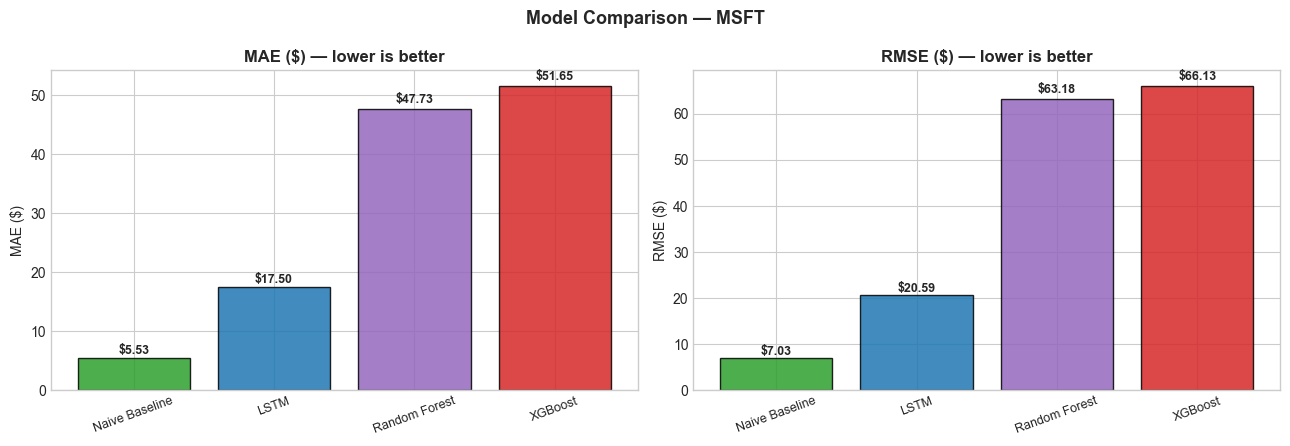

In [24]:
def metrics(y_true, y_pred, label=''):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    mape = np.mean(np.abs((np.array(y_true) - np.array(y_pred)) / (np.array(y_true) + 1e-9))) * 100
    return {'Model': label, 'MAE ($)': round(mae,2), 'RMSE ($)': round(rmse,2),
            'R² (%)': round(r2*100,2), 'MAPE (%)': round(mape,2)}

results = []
preds_dict = {}

for name, model in models.items():
    p = model.predict(X_test)
    preds_dict[name] = p
    results.append(metrics(y_test, p, name))

# LSTM — align lengths (LSTM test starts LOOKBACK days in)
lstm_offset = len(y_test) - len(lstm_preds)
y_test_lstm = y_test.values[lstm_offset:]
dates_lstm  = test_dates.iloc[lstm_offset:]
preds_dict['LSTM'] = (lstm_preds, dates_lstm, y_test_lstm)
results.append(metrics(y_test_lstm, lstm_preds, 'LSTM'))

# Naive baseline
results.append(metrics(y_test, y_baseline, 'Naive Baseline'))

df_results = pd.DataFrame(results).set_index('Model').sort_values('MAE ($)')
print("=" * 60)
print(f"  MODEL COMPARISON — {COMPANY_NAME} ({TICKER})")
print("=" * 60)
display(df_results)
print("=" * 60)

# ── Bar chart ──
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
fig.suptitle(f'Model Comparison — {TICKER}', fontsize=13, fontweight='bold')

colors = ['#2ca02c','#1f77b4','#9467bd','#d62728']
for ax, metric in zip(axes, ['MAE ($)', 'RMSE ($)']):
    vals  = df_results[metric].values
    names = df_results.index.tolist()
    bars  = ax.bar(names, vals, color=colors[:len(names)], edgecolor='black', alpha=0.85)
    ax.set_title(f'{metric} — lower is better', fontweight='bold')
    ax.set_ylabel(metric)
    ax.tick_params(axis='x', rotation=20, labelsize=9)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.01,
                f'${v:.2f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
plt.tight_layout()
plt.show()


## 9. Predictions vs Actual (Test Period)

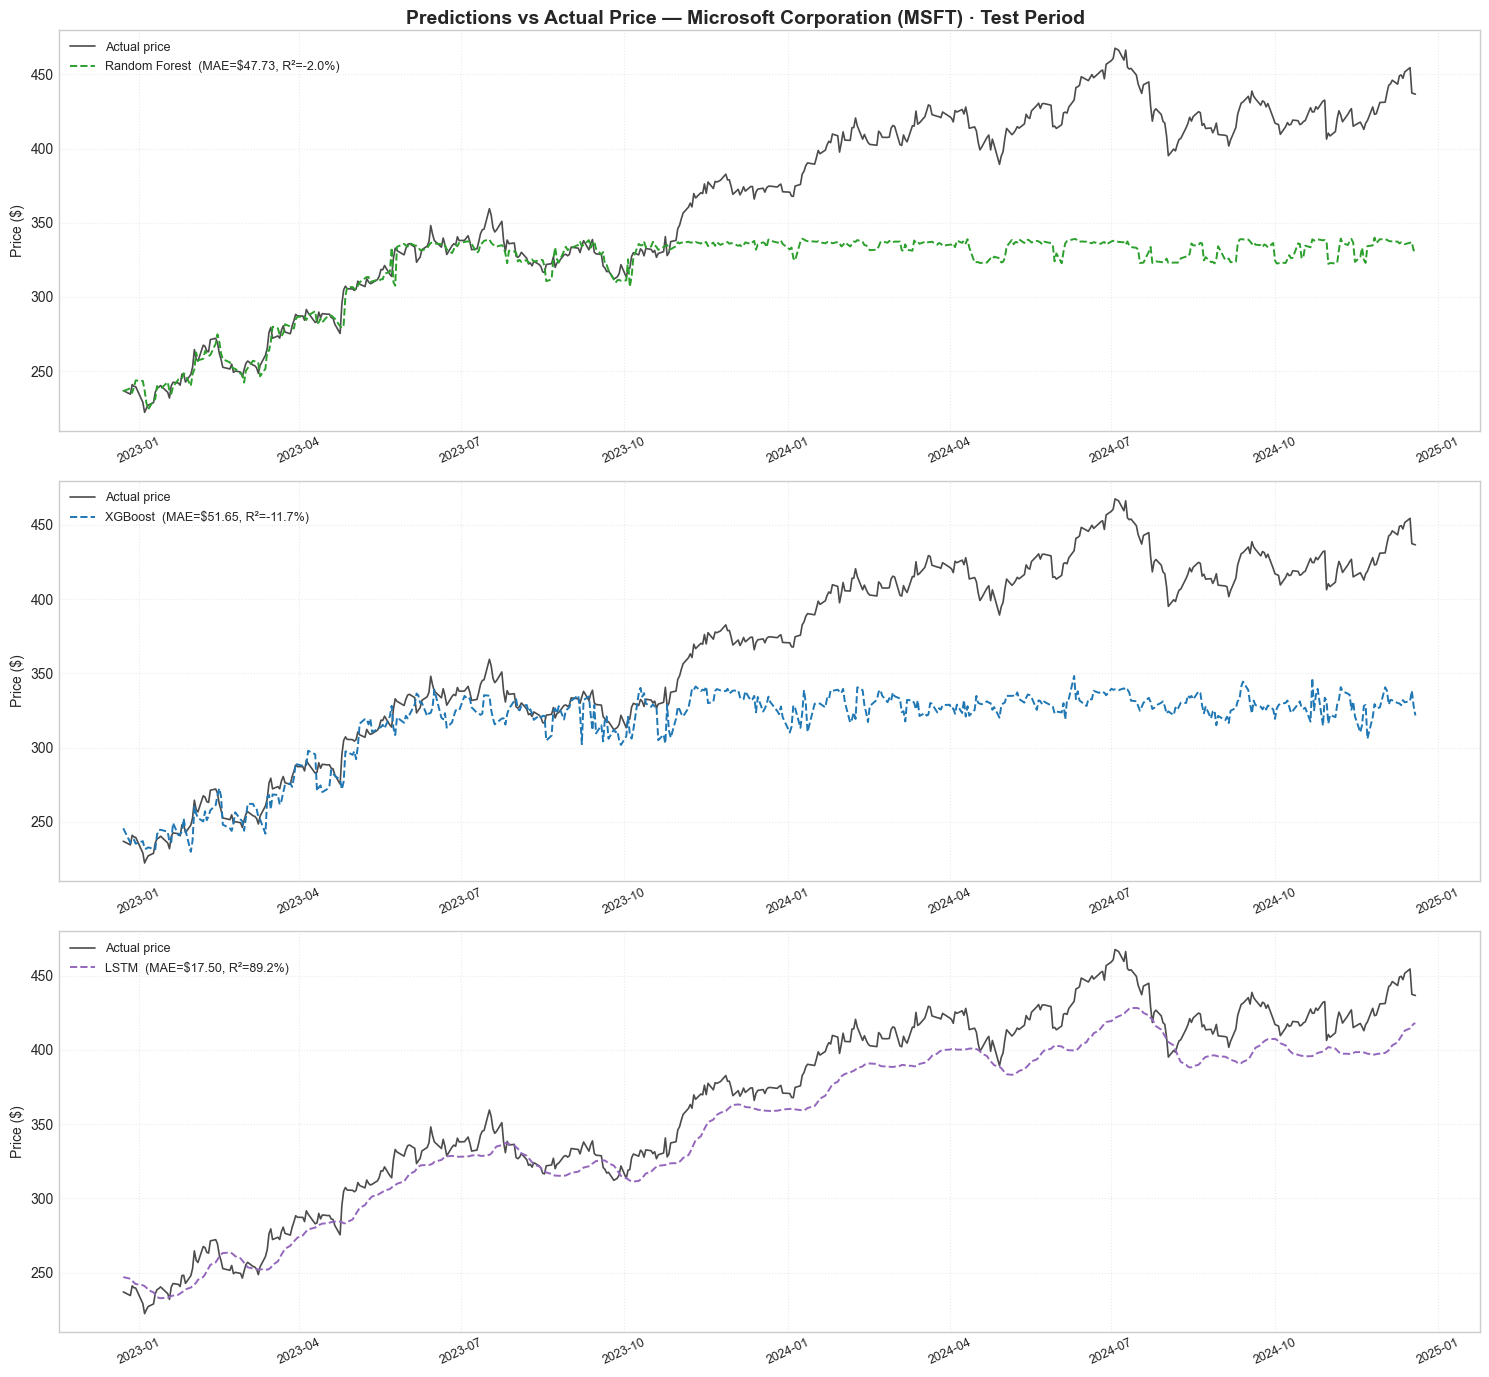

In [25]:
fig, axes = plt.subplots(3, 1, figsize=(15, 14))
fig.suptitle(f'Predictions vs Actual Price — {COMPANY_NAME} ({TICKER}) · Test Period',
             fontsize=14, fontweight='bold')

plot_configs = [
    ('Random Forest', preds_dict['Random Forest'], test_dates, y_test.values, '#2ca02c'),
    ('XGBoost',       preds_dict['XGBoost'],       test_dates, y_test.values, '#1f77b4'),
    ('LSTM',          lstm_preds,                  dates_lstm, y_test_lstm,   '#9467bd'),
]

for ax, (name, preds, dates, actual, color) in zip(axes, plot_configs):
    mae = mean_absolute_error(actual, preds)
    r2  = r2_score(actual, preds)
    ax.plot(dates, actual, color='black', linewidth=1.2, alpha=0.7, label='Actual price')
    ax.plot(dates, preds,  color=color,  linewidth=1.4, linestyle='--', label=f'{name}  (MAE=${mae:.2f}, R²={r2*100:.1f}%)')
    ax.set_ylabel('Price ($)')
    ax.legend(fontsize=9, loc='upper left')
    ax.grid(True, linestyle=':', alpha=0.4)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    ax.tick_params(axis='x', rotation=25, labelsize=9)

plt.tight_layout()
plt.show()


## 10. Zoom — One Representative Month

Showing: January 2024  (21 trading days)


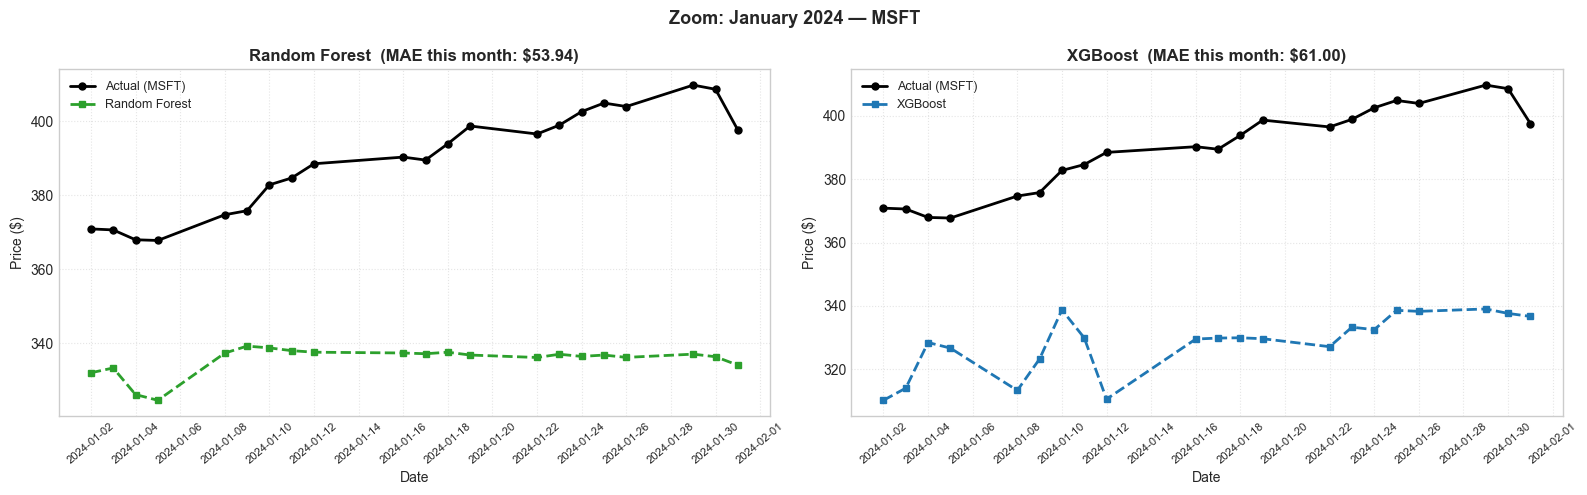

In [26]:
# Auto-detect: use the last January in the test period; fallback to last month
test_df = df_ml.iloc[SPLIT:].copy()
test_df['RF_pred']   = preds_dict['Random Forest']
test_df['XGB_pred']  = preds_dict['XGBoost']
test_df['ARIMA_pred'] = np.nan   # placeholder — not used here

test_periods = test_df['Date'].dt.to_period('M')
jan_periods  = test_periods[test_df['Date'].dt.month == 1].unique()

if len(jan_periods) > 0:
    target_period = jan_periods[-1]
    period_label  = f"January {target_period.year}"
else:
    target_period = test_periods.max()
    period_label  = str(target_period)

zoom_df = test_df[test_periods == target_period].copy()
if len(zoom_df) < 5:
    zoom_df = test_df.tail(20).copy()
    period_label = "Last 20 trading days"

print(f"Showing: {period_label}  ({len(zoom_df)} trading days)")

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle(f'Zoom: {period_label} — {TICKER}', fontsize=13, fontweight='bold')

for ax, (name, col, color) in zip(axes, [
    ('Random Forest', 'RF_pred',  '#2ca02c'),
    ('XGBoost',       'XGB_pred', '#1f77b4'),
]):
    ax.plot(zoom_df['Date'], zoom_df['Close'], marker='o', color='black',
            linewidth=2, markersize=5, label=f'Actual ({TICKER})')
    ax.plot(zoom_df['Date'], zoom_df[col], marker='s', color=color,
            linewidth=2, linestyle='--', markersize=5, label=name)
    mae_z = mean_absolute_error(zoom_df['Close'], zoom_df[col])
    ax.set_title(f'{name}  (MAE this month: ${mae_z:.2f})', fontweight='bold')
    ax.set_xlabel('Date')
    ax.set_ylabel('Price ($)')
    ax.legend(fontsize=9)
    ax.grid(True, linestyle=':', alpha=0.5)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
    ax.xaxis.set_major_locator(mdates.DayLocator(interval=2))
    ax.tick_params(axis='x', rotation=40, labelsize=8)

plt.tight_layout()
plt.show()


## 11. Feature Importance (XGBoost)

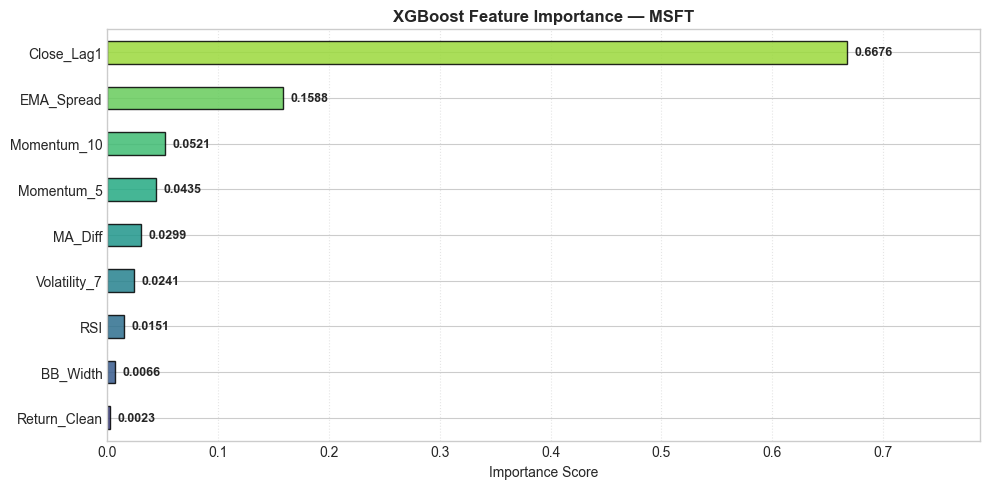

In [27]:
feat_imp = pd.Series(
    models['XGBoost'].feature_importances_, index=FEATURES
).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 5))
colors_bar = plt.cm.viridis(np.linspace(0.2, 0.85, len(feat_imp)))
feat_imp.plot(kind='barh', ax=ax, color=colors_bar, edgecolor='black', alpha=0.85)
ax.set_title(f'XGBoost Feature Importance — {TICKER}', fontweight='bold', fontsize=12)
ax.set_xlabel('Importance Score')
max_v = feat_imp.max()
for i, v in enumerate(feat_imp.values):
    ax.text(v + max_v*0.01, i, f'{v:.4f}', va='center', fontsize=9, fontweight='bold')
ax.set_xlim(0, max_v * 1.18)
ax.grid(True, linestyle=':', alpha=0.5, axis='x')
plt.tight_layout()
plt.show()


## 12. Future Forecast — Next 20 Trading Days

Best model: LSTM


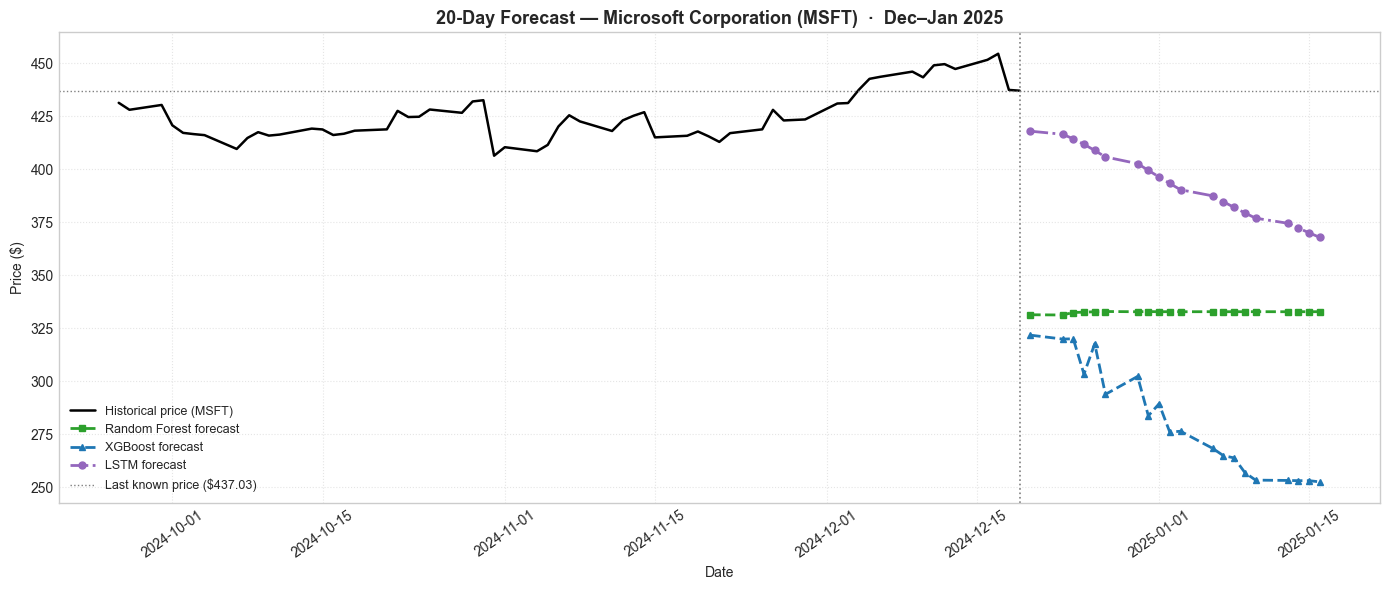


Forecast summary for Dec–Jan 2025:
  Random Forest : start $331.32  →  end $332.77
  XGBoost       : start $321.69  →  end $252.45
  LSTM          : start $417.92  →  end $367.78


In [28]:
# ── Find the winner model (lowest MAE) ──
winner_name = df_results.drop('Naive Baseline')['MAE ($)'].idxmin()
print(f"Best model: {winner_name}")

last_date   = df_ml['Date'].iloc[-1]
future_dates = pd.date_range(
    start=last_date + pd.tseries.offsets.BDay(1),
    periods=20, freq='B'
)
future_label = f"{future_dates[0].strftime('%b')}–{future_dates[-1].strftime('%b %Y')}"

# ── RF / XGB recursive forecast ──
def recursive_forecast_ml(model, last_features, n=20):
    preds = []
    feat = last_features.copy()
    feat_idx = {name: FEATURES.index(name) for name in FEATURES}
    current_close = df_ml['Close'].iloc[-1]

    for _ in range(n):
        feat_scaled = scaler.transform(feat.reshape(1, -1))
        pred = model.predict(feat_scaled)[0]
        preds.append(pred)

        prev_close = current_close
        current_close = pred

        if 'Close_Lag1'  in feat_idx: feat[feat_idx['Close_Lag1']]  = prev_close
        if 'Momentum_5'  in feat_idx: feat[feat_idx['Momentum_5']]  = current_close - prev_close
        if 'Momentum_10' in feat_idx: feat[feat_idx['Momentum_10']] = current_close - prev_close
    return preds

last_feat_raw = df_ml[FEATURES].iloc[-1].values.copy()
rf_future  = recursive_forecast_ml(models['Random Forest'], last_feat_raw)
xgb_future = recursive_forecast_ml(models['XGBoost'],      last_feat_raw)

# ── LSTM rolling-window forecast ──
lstm_window = all_prices_scaled[-LOOKBACK:].copy()
lstm_future = []
for _ in range(20):
    x_in = lstm_window.reshape(1, LOOKBACK, 1)
    pred_scaled = lstm_model.predict(x_in, verbose=0)[0, 0]
    pred_price  = lstm_scaler.inverse_transform([[pred_scaled]])[0, 0]
    lstm_future.append(pred_price)
    lstm_window = np.roll(lstm_window, -1, axis=0)
    lstm_window[-1, 0] = pred_scaled

# ── Plot ──
last_price = df_ml['Close'].iloc[-1]

# Show last 60 days of actual data for context
context_df = df_ml.tail(60)

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(context_df['Date'], context_df['Close'],
        color='black', linewidth=1.8, label=f'Historical price ({TICKER})')
ax.axvline(last_date, color='gray', linestyle=':', linewidth=1.2)
ax.plot(future_dates, rf_future,   marker='s', color='#2ca02c', linestyle='--',
        linewidth=2, markersize=5, label='Random Forest forecast')
ax.plot(future_dates, xgb_future,  marker='^', color='#1f77b4', linestyle='--',
        linewidth=2, markersize=5, label='XGBoost forecast')
ax.plot(future_dates, lstm_future, marker='o', color='#9467bd', linestyle='-.',
        linewidth=2, markersize=5, label='LSTM forecast')
ax.axhline(last_price, color='gray', linestyle=':', linewidth=1,
           label=f'Last known price (${last_price:.2f})')

ax.set_title(f'20-Day Forecast — {COMPANY_NAME} ({TICKER})  ·  {future_label}',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Price ($)')
ax.legend(fontsize=9, loc='best')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
ax.tick_params(axis='x', rotation=35)
ax.grid(True, linestyle=':', alpha=0.5)
plt.tight_layout()
plt.show()

print(f"\nForecast summary for {future_label}:")
print(f"  Random Forest : start ${rf_future[0]:.2f}  →  end ${rf_future[-1]:.2f}")
print(f"  XGBoost       : start ${xgb_future[0]:.2f}  →  end ${xgb_future[-1]:.2f}")
print(f"  LSTM          : start ${lstm_future[0]:.2f}  →  end ${lstm_future[-1]:.2f}")
